In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calplot
import requests
import warnings

In [8]:
# OData v4 endpoints
url_hist = "https://data.sfgov.org/api/odata/v4/tmnf-yvry"
url_recent = "https://data.sfgov.org/api/odata/v4/wg3w-h783"

In [9]:
# fucntion to get data from OData endpoint
def fetch_odata(url):
    response = requests.get(url).json()
    # take the 'value' key which contains the list of records and convert to DataFrame
    # convert json to DataFrame
    return pd.DataFrame(response['value'])

In [10]:
print("getting data from API...")
df_hist = fetch_odata(url_hist)
df_recent = fetch_odata(url_recent)
# get the data from the API and store in DataFrames
print("done.")

getting data from API...


In [11]:
print("2018-present:", df_recent.columns.tolist())
print("2003-2018:", df_hist.columns.tolist())
# check the column names to see how to adapt the datasets

2018-present: ['__id', 'row_id', 'incident_datetime', 'incident_date', 'incident_time', 'incident_year', 'incident_day_of_week', 'report_datetime', 'incident_id', 'incident_number', 'cad_number', 'report_type_code', 'report_type_description', 'filed_online', 'incident_code', 'incident_category', 'incident_subcategory', 'incident_description', 'resolution', 'intersection', 'cnn', 'police_district', 'analysis_neighborhood', 'supervisor_district', 'supervisor_district_2012', 'latitude', 'longitude', 'point', 'data_as_of', 'data_loaded_at']
2003-2018: ['__id', 'pdid', 'incidntnum', 'incident_code', 'category', 'descript', 'dayofweek', 'date', 'time', 'pddistrict', 'resolution', 'address', 'x', 'y', 'location', 'data_loaded_at']


In [12]:
# adaptation of the historical dataset (2003-2018)
# we select the relevant columns and rename them to standard names
df_hist_raw = df_hist.copy() #copy of the original dataframe
df_hist = df_hist_raw[['category', 'date', 'time', 'pddistrict', 'x', 'y']].copy() #select relevant columns
df_hist.columns = ['category', 'date', 'time', 'district', 'longitude', 'latitude'] # rename to standard names

In [14]:
# adaptation of the new dataset (2018-present)
# here we use the new column names from your print overview
df_recent_raw = df_recent.copy() #copy of the original dataframe
df_recent = df_recent_raw[['incident_category', 'incident_date', 'incident_time', 'police_district', 'longitude', 'latitude']].copy() #select relevant columns
df_recent.columns = ['category', 'date', 'time', 'district', 'longitude', 'latitude'] # rename to standard names

In [15]:
# cleaning and merging
# make categories uniform (lowercase)
df_hist['category'] = df_hist['category'].str.lower()
df_recent['category'] = df_recent['category'].str.lower()

In [16]:
# make category names more uniform (e.g. 'motor vehicle theft' vs 'vehicle theft')
df_recent['category'] = df_recent['category'].replace({'motor vehicle theft': 'vehicle theft'})

In [17]:
# gather the two datasets into one
df_total = pd.concat([df_hist, df_recent], ignore_index=True)

In [19]:
# convert date column to datetime
df_total['date'] = pd.to_datetime(df_total['date'], format='mixed')

In [20]:
print(f"data gathered - rows in all: {len(df_total)}")
print(df_total.head())

data gathered - rows in all: 2000
         category       date   time   district   longitude   latitude
0   vehicle theft 2016-03-03  19:30    TARAVAL -122.463545  37.707968
1         assault 2006-09-25  22:15   NORTHERN -122.425839  37.778486
2        trespass 2011-06-19  13:06    TARAVAL -122.466758  37.729185
3         assault 2005-07-23  16:40  INGLESIDE -122.420084  37.708311
4  other offenses 2004-06-24  13:00    MISSION -120.500000  90.000000


In [25]:
assault_df = df_total[df_total['category'] == 'assault'].copy()
assault_df['day'] = assault_df['date'].dt.day_name()

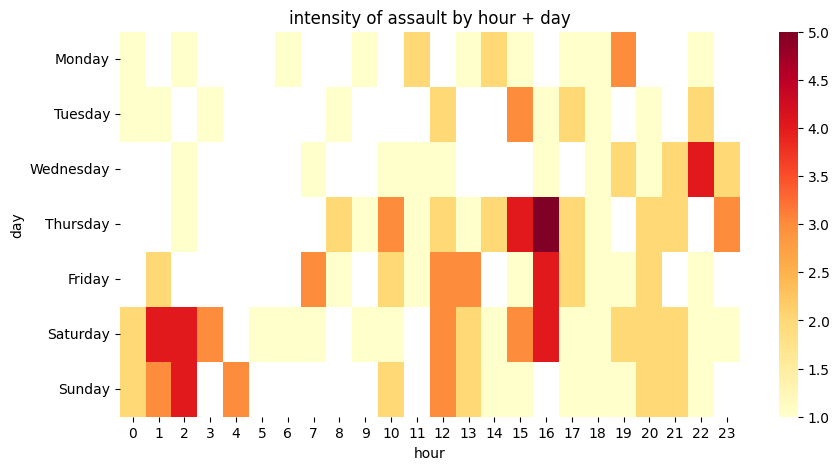

In [31]:
assault_df['hour'] = pd.to_datetime(assault_df['time'], format='%H:%M').dt.hour

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = assault_df.groupby(['day', 'hour']).size().unstack().reindex(days)

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("intensity of assault by hour + day")
plt.show()

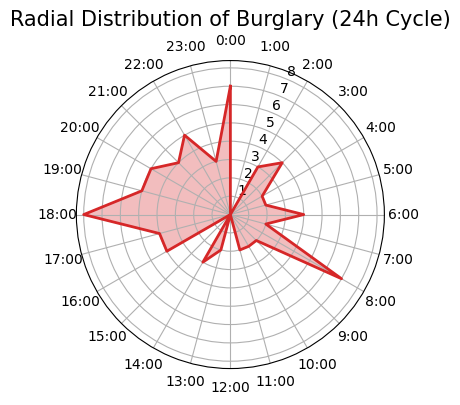

In [36]:
# choose a crime type to visualize
crime_type = 'burglary' # you can change this to any crime type present in the 'category' column, e.g. 'assault', 'vehicle theft', etc.
crime_df = df_total[df_total['category'] == crime_type].copy() #filter the dataset to only include the chosen crime type

# extract hour from time column
crime_df['hour'] = pd.to_datetime(crime_df['time'], format='%H:%M').dt.hour

polar_data = crime_df['hour'].value_counts().sort_index()

# Make sure we have counts for all 24 hours (0-23), filling missing hours with 0
counts = [polar_data.get(i, 0) for i in range(24)]
hours = np.arange(0, 24)

# calculate angles for each hour (360 degrees / 24 hours = 15 degrees per hour)
angles = np.linspace(0, 2 * np.pi, len(hours), endpoint=False).tolist()

# end the plot by connecting the last point to the first
counts += counts[:1]
angles += angles[:1]

# plotting
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'polar'}) #change the size of the plot to make it more compact

ax.plot(angles, counts, color='#d62728', linewidth=2) #plot the line connecting the points
ax.fill(angles, counts, color='#d62728', alpha=0.3) #fill the area under the line with a color and some transparency

# make it look like a clock
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# set the hour labels around the plot
ax.set_thetagrids(np.degrees(angles[:-1]), labels=[f"{h}:00" for h in hours]) #set the labels to show hours in 24h format

plt.title(f'Radial Distribution of {crime_type.capitalize()} (24h Cycle)', size=15) #add title to the plot
plt.show()

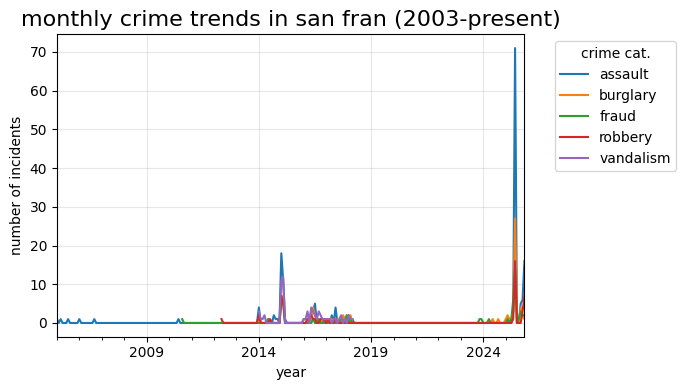

In [41]:
# for the monthly trends, we need to set the date as index and then resample by month
# ensure we use the correct column name (lowercase 'date' or uppercase 'Date')
df_ts = df_total.set_index('date')

# define the focus crimes inside the cell to avoid NameError
my_focus_crimes = ['assault', 'burglary', 'robbery', 'vandalism', 'fraud']

# Filter for the selected focus crimes
df_ts = df_ts[df_ts['category'].isin(my_focus_crimes)]

# we group by category and resample to months ('ME' = month end)
# .unstack(0) makes it so that each category gets its own line
monthly_trends = df_ts.groupby('category').resample('ME').size().unstack(0)

plt.figure(figsize=(7, 4)) #change the size of the plot to make it wider and more readable
monthly_trends.plot(ax=plt.gca(), linewidth=1.5) #plot the monthly trends for each category on the same axes, with a specified line width

plt.title('monthly crime trends in san fran (2003-present)', size=16) #add title to the plot
plt.xlabel('year')
plt.ylabel('number of incidents')
plt.legend(title='crime cat.', bbox_to_anchor=(1.05, 1), loc='upper left') #move the legend outside the plot area to the right
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


plotting data for year: 2025 (17 days found)


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


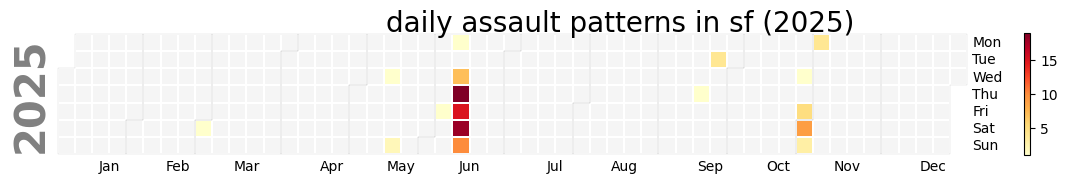

In [55]:
# 1. remove the annoying font warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# 2. prepare data and check contents
# ensure 'category' is lowercase, as we check against 'assault'
cal_data = df_total[df_total['category'].str.lower() == 'assault'].groupby('date').size()

# check if we found any data at all
if cal_data.empty:
    print("error: no data found for category 'assault'. check your category names!")
else:
    cal_data.index = pd.to_datetime(cal_data.index)
    
    # find the newest year we have in the dataset instead of guessing
    latest_year = cal_data.index.year.max()
    cal_data_filtered = cal_data[cal_data.index.year == latest_year]

    print(f"plotting data for year: {latest_year} ({len(cal_data_filtered)} days found)")

    if not cal_data_filtered.empty:
        # 3. create the plot
        # remove suptitle_kws/font-settings that can trigger helvetica errors
        fig, axes = calplot.calplot(cal_data_filtered, 
                                    cmap='YlOrRd', 
                                    edgecolor='gray', 
                                    linewidth=0.1)
        
        # add title manually to avoid font issues in suptitle
        plt.suptitle(f'daily assault patterns in sf ({latest_year})', fontsize=20, y=1.05)
        plt.show()
    else:
        print(f"no data found for year {latest_year}")

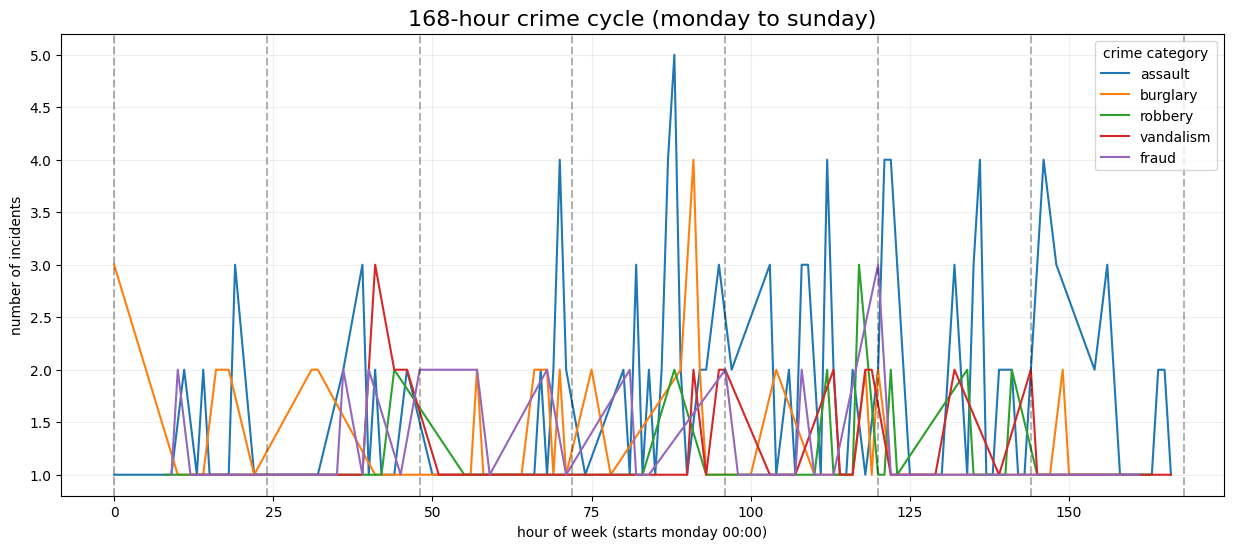

In [56]:
# ensure we have the day of week and hour columns in lowercase
df_total['day_of_week'] = df_total['date'].dt.day_name().str.lower()
df_total['hour'] = pd.to_datetime(df_total['time'], format='%H:%M').dt.hour

# create a combined column for the 168 hours of the week
# we map days to numbers to sort them correctly: monday=0, sunday=6
day_map = {'monday': 0, 'tuesday': 1, 'wednesday': 2, 'thursday': 3, 'friday': 4, 'saturday': 5, 'sunday': 6}
df_total['day_num'] = df_total['day_of_week'].map(day_map)
df_total['hour_of_week'] = df_total['day_num'] * 24 + df_total['hour']

# plot the 168-hour cycle for focus crimes
plt.figure(figsize=(15, 6))
for crime in my_focus_crimes:
    subset = df_total[df_total['category'] == crime]
    data_168 = subset.groupby('hour_of_week').size()
    plt.plot(data_168.index, data_168.values, label=crime)

# add vertical lines to mark each new day
for i in range(0, 169, 24):
    plt.axvline(x=i, color='black', linestyle='--', alpha=0.3)

plt.title('168-hour crime cycle (monday to sunday)', size=16)
plt.xlabel('hour of week (starts monday 00:00)')
plt.ylabel('number of incidents')
plt.legend(title='crime category')
plt.grid(True, alpha=0.2)
plt.show()

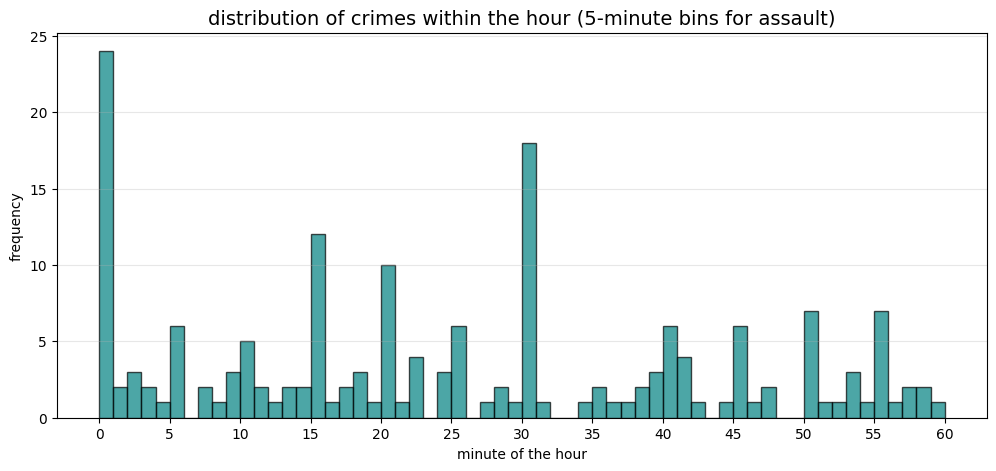

In [57]:
# we need to combine date and time to get a full timestamp for fine-grained binning
df_total['timestamp'] = pd.to_datetime(df_total['date'].dt.date.astype(str) + ' ' + df_total['time'])

# select a crime with lots of data, e.g., 'assault'
subset_5min = df_total[df_total['category'] == 'assault']

# extract only the minute of the hour to see the distribution
minutes = subset_5min['timestamp'].dt.minute

plt.figure(figsize=(12, 5))
plt.hist(minutes, bins=60, range=(0, 60), color='teal', edgecolor='black', alpha=0.7)
plt.title('distribution of crimes within the hour (5-minute bins for assault)', size=14)
plt.xlabel('minute of the hour')
plt.ylabel('frequency')
plt.xticks(range(0, 61, 5))
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Exercise 2.2**
___
To ensure a consistent analysis across the two decades of San Francisco crime data, I have selected a set of Personal Focus Crimes. These categories have been chosen because they represent significant criminal activities, are consistently recorded in both the historical (2003-2018) and recent (2018-present) datasets, and provide enough data points for robust temporal analysis.

* **Justification and Methodology:**
Case Normalization: The historical data used ALL CAPS while the recent data uses Title Case. All categories have been standardized to lowercase in the merged dataset to avoid duplicate entries.

* **Confidence Level:** 
I have assigned a High confidence level to these mappings because the definitions and reporting standards for these specific crimes have remained relatively stable in San Francisco over the 20-year period.

* **Excluded Categories:** 
I chose to exclude categories like "Other Offenses" or "Non-Criminal" as they are too broad for specific temporal pattern analysis and often vary significantly in how they are reported across different police districts.